In [133]:
import cv2
import scipy
import os
from random import random
import time
import scipy as sp
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import scipy.sparse as sparse
from scipy.sparse.linalg import spsolve
import scipy.signal as signal

In [134]:
def get_image(img_path: str, mask: bool=False, scale: bool=True) -> np.array:
    if mask:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        _, binary_mask = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        return np.where(binary_mask == 255, 1, 0)
    
    if scale:
        return cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB).astype('double') / 255.0
    
    return cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)


def show_images(imgs: List[np.array], titles: List[str], figsize: Tuple[int]=(15, 10)) -> None:
    idx = 1
    fig = plt.figure(figsize=figsize)

    for img, title in zip(imgs, titles):
        ax = fig.add_subplot(1, len(imgs), idx)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(title)
        idx += 1
    plt.show()

In [135]:
def neighbours(i: int, j: int, max_i: int, max_j: int) -> List[Tuple[int, int]]:
    pairs = []

    for n in [-1, 1]:
        if 0 <= i + n < max_i:
            pairs.append((i + n, j))
        if 0 <= j + n < max_j:
            pairs.append((i, j + n))

    return pairs

In [136]:
def getIndexes(mask, targetH, targetW, offsetX=0, offsetY=0):

    x, y = np.meshgrid(np.arange(mask.shape[1]), np.arange(mask.shape[0]))
    target_x, target_y = x[mask > 0], y[mask > 0]

    indexes = np.zeros((targetH, targetW), dtype=np.int32)

    indexes[target_y + offsetY, target_x + offsetX] = np.arange(1, len(target_x)+1)

    return indexes

In [137]:
def getCoefficientMatrix(indexes):

    Y, X = np.nonzero(indexes)

    row = np.arange(0, len(Y))
    col = np.arange(0, len(Y))
    data = 4 * np.ones(len(Y))

    N = np.count_nonzero(indexes)

    left = np.zeros(N, dtype=np.int32)
    valid = X - 1 >= 0
    left[valid] = indexes[Y[valid], (X - 1)[valid]]

    right = np.zeros(N, dtype=np.int32)
    valid = X + 1 < len(indexes[0])
    right[valid] = indexes[Y[valid], (X + 1)[valid]]

    up = np.zeros(N, dtype=np.int32)
    valid = Y - 1 >= 0
    up[valid] = indexes[(Y - 1)[valid], X[valid]]

    down = np.zeros(N, dtype=np.int32)
    valid = Y + 1 < len(indexes)
    down[valid] = indexes[(Y + 1)[valid], X[valid]]

    all = [left, right, up, down]

    for a in all:

        vals = np.arange(1, len(Y) + 1)

        valid = np.logical_and(a, vals>0)

        vals = [vals[i] - 1 for i in range(len(valid)) if valid[i] == True]
        a = [a[i] - 1 for i in range(len(valid)) if valid[i] == True]

        valid = -1 * np.ones(len(vals))

        row = np.concatenate((row, vals))
        col = np.concatenate((col, a))
        data = np.concatenate((data, valid))

    return scipy.sparse.csr_matrix((data,(row,col)))

In [138]:
def getSolutionVect(indexes, source, target, offsetX, offsetY):

    laplacian = np.array([[0,-1,0],
                          [-1,4,-1],
                          [0,-1,0]])

    source_laplacian = signal.convolve2d(source, laplacian, 'same')

    w,h = target.shape[1], target.shape[0]
    x,y = np.meshgrid(np.arange(w), np.arange(h))

    x_left=(x-1).clip(0,w-1)
    left=target[y,x_left]
    indexes_left=indexes[y,x_left]

    x_right=(x+1).clip(0,w-1)
    right=target[y,x_right]
    indexes_right=indexes[y,x_right]

    y_up=(y-1).clip(0,h-1)
    up=target[y_up,x]
    indexes_up=indexes[y_up,x]

    y_down=(y+1).clip(0,h-1)
    down=target[y_down,x]
    indexes_down=indexes[y_down,x]

    Y,X=np.nonzero(indexes)
    N=np.count_nonzero(indexes)

    b=np.zeros((1,N))

    for (j,i) in list(zip(Y,X)):

        val = source_laplacian[j-offsetY, i-offsetX]

        if indexes_left[j,i]==0:
            val += left[j,i]

        if indexes_right[j,i]==0:
            val += right[j,i]

        if indexes_up[j,i]==0:
            val += up[j,i]

        if indexes_down[j,i]==0:
            val += down[j,i]

        b[0][indexes[j][i]-1]=val

    return b

In [139]:
def solveEqu(A,b):
    return spsolve(A,b)

In [140]:
def reconstructImg(indexes, red, green, blue, targetImg):

    Y,X=np.nonzero(indexes)

    newValues=np.dstack((red,green,blue))

    copyImg=np.copy(targetImg)

    for (j,i) in list(zip(Y,X)):

        for z in range(3):

            copyImg[j][i][z]=newValues[0][int(indexes[j][i]-1)][z]

    return copyImg

In [141]:
def seamlessCloningPoisson(sourceImg,targetImg,mask,offsetX,offsetY):

    indexes=getIndexes(mask,targetImg.shape[0],targetImg.shape[1],offsetX,offsetY)

    A=getCoefficientMatrix(indexes)

    red,green,blue=[
        getSolutionVect(indexes,sourceImg[:,:,i],targetImg[:,:,i],offsetX,offsetY).T
        for i in range(3)
    ]

    new_red,new_green,new_blue=[
        solveEqu(A,channel)
        for channel in [red,green,blue]
    ]

    resultImg=reconstructImg(indexes,new_red,new_green,new_blue,targetImg)

    return resultImg

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27359664..1.1302451].


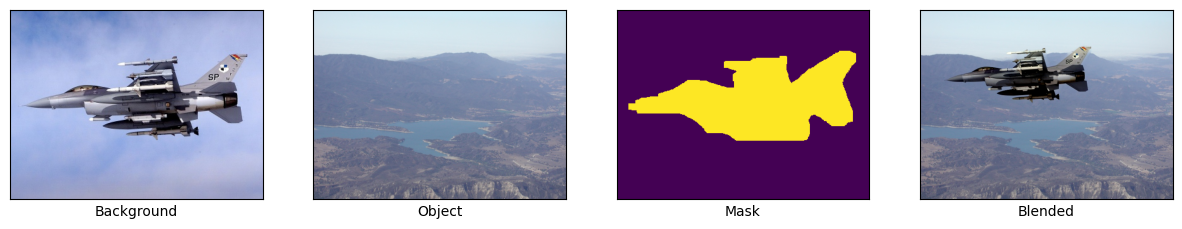

In [142]:
src_path='input/source_3.jpg'
src=np.array(Image.open(src_path).convert('RGB'),'f')/255

target_path='input/target_3.jpg'
# target_path='input/source_4.webp'
target=np.array(Image.open(target_path).convert('RGB'),'f')/255

mask_path='input/mask_3.bmp'
mask=np.array(Image.open(mask_path))>0

offsetX=40
offsetY=20

result=seamlessCloningPoisson(src,target,mask,offsetX,offsetY)

show_images(
    [src, target, mask, result], 
    ["Background", "Object", "Mask", "Blended"]
)

In [143]:
cloned = Image.fromarray((np.clip(result,0,1)*255).astype(np.uint8))
cloned.save("cloned.png")

In [144]:
def poisson_blend(img_s: np.ndarray, mask: np.ndarray, img_t: np.ndarray) -> np.ndarray:
    img_s_h, img_s_w = img_s.shape
    
    nnz = (mask>0).sum()
    im2var = -np.ones(mask.shape[0:2], dtype='int32')
    im2var[mask>0] = np.arange(nnz)
    
    ys, xs = np.where(mask==1) 
        
    A = sp.sparse.lil_matrix((4*nnz, nnz))
    b = np.zeros(4*nnz)
    
    e = 0
    for n in range(nnz):
        y, x = ys[n], xs[n]  
        
        for n_y, n_x in neighbours(y, x, img_s_h-1, img_s_w-1):
            A[e, im2var[y][x]] = 1
            b[e] = img_s[y][x] - img_s[n_y][n_x]
            
            if im2var[n_y][n_x] != -1:
                A[e, im2var[n_y][n_x]] = -1
            else:
                b[e] += img_t[n_y][n_x]
            e += 1
    
    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]
    
    img_t_out = img_t.copy()
    
    for n in range(nnz):
        y, x = ys[n], xs[n]
        img_t_out[y][x] = v[im2var[y][x]]
    
    return np.clip(img_t_out, 0, 1)

In [145]:
def mixed_blend(img_s: np.ndarray, mask: np.ndarray, img_t: np.ndarray) -> np.ndarray:
    img_s_h, img_s_w = img_s.shape
    
    nnz = (mask>0).sum()
    im2var = -np.ones(mask.shape[0:2], dtype='int32')
    im2var[mask>0] = np.arange(nnz)
    
    ys, xs = np.where(mask==1) 
        
    A = sp.sparse.lil_matrix((4*nnz, nnz))
    b = np.zeros(4*nnz)
    
    e = 0
    for n in range(nnz):
        y, x = ys[n], xs[n]  
        
        for n_y, n_x in neighbours(y, x, img_s_h-1, img_s_w-1):
            ds = img_s[y][x] - img_s[n_y][n_x]
            dt = img_t[y][x] - img_t[n_y][n_x]
            d = ds if abs(ds) > abs(dt) else dt
            
            A[e, im2var[y][x]] = 1
            b[e] = d
            
            if im2var[n_y][n_x] != -1:
                A[e, im2var[n_y][n_x]] = -1
            else:
                b[e] += img_t[n_y][n_x]
            e += 1
    
    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]
    
    img_t_out = img_t.copy()
    
    for n in range(nnz):
        y, x = ys[n], xs[n]
        img_t_out[y][x] = v[im2var[y][x]]
    
    return np.clip(img_t_out, 0, 1)

In [146]:
bg_img = get_image('input/obj.jpg')
# obj_img = get_image('input/img4.jpg')
obj_img = get_image('input/obj_2.jpg')
mask_img =  get_image('input/mask2.jpg', mask=True)

In [147]:
def center_on_canvas(obj, mask, canvas_h, canvas_w, bg_val=0, mask_val=0):
    h, w = obj.shape[:2]
    y0 = (canvas_h - h) // 2
    x0 = (canvas_w - w) // 2

    # nếu obj là RGB
    if obj.ndim == 3:
        obj_canvas = np.full((canvas_h, canvas_w, obj.shape[2]), bg_val, dtype=obj.dtype)
        obj_canvas[y0:y0+h, x0:x0+w, :] = obj
    else:
        obj_canvas = np.full((canvas_h, canvas_w), bg_val, dtype=obj.dtype)
        obj_canvas[y0:y0+h, x0:x0+w] = obj

    mask_canvas = np.full((canvas_h, canvas_w), mask_val, dtype=mask.dtype)
    mask_canvas[y0:y0+h, x0:x0+w] = mask

    return obj_canvas, mask_canvas, (x0, y0)

H, W = bg_img.shape[:2]
obj_centered, mask_centered, (x0,y0) = center_on_canvas(obj_img, mask_img, H, W)

mix_img = np.zeros(bg_img.shape, dtype=bg_img.dtype)
for b in range(3):
    mix_img[:,:,b] = mixed_blend(obj_centered[:,:,b], mask_centered, bg_img[:,:,b].copy())

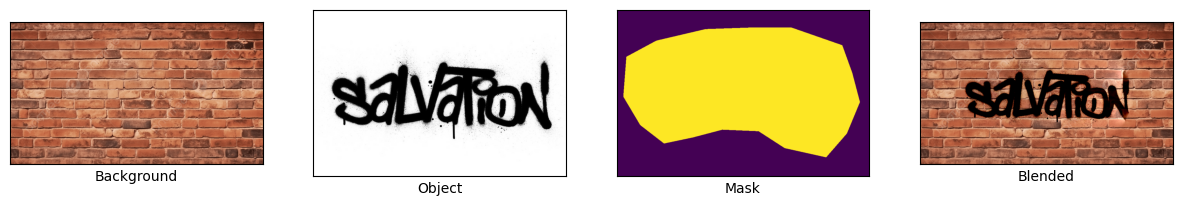

In [148]:
show_images(
    [bg_img, obj_img, mask_img, mix_img], 
    ["Background", "Object", "Mask", "Blended"]
)

In [149]:
def _2d_gaussian(sigma: float) -> np.ndarray:
    ksize = int(np.ceil(sigma)*6+1)
    gaussian_1d = cv2.getGaussianKernel(ksize, sigma)
    
    return gaussian_1d * np.transpose(gaussian_1d)

def _low_pass_filter(img: np.ndarray, sigma: float) -> np.ndarray:
    return cv2.filter2D(img, -1, _2d_gaussian(sigma))

def _high_pass_filter(img: np.ndarray, sigma: float) -> np.ndarray:
    return img - _low_pass_filter(img, sigma)

def _gaus_pyramid(img: np.ndarray, depth: int, sigma: int) -> List[np.ndarray]:
    _im = img.copy()
    
    pyramid = []
    for d in range(depth-1):
        _im = _low_pass_filter(_im.copy(), sigma)
        pyramid.append(_im)
        _im = cv2.pyrDown(_im)
        
    return pyramid 

def _lap_pyramid(img: np.ndarray, depth: int, sigma: int) -> List[np.ndarray]:
    _im = img.copy()
    
    pyramid = []
    for d in range(depth-1):
        lap = _high_pass_filter(_im.copy(), sigma)
        pyramid.append(lap)
        _im = cv2.pyrDown(_im)
        
    return pyramid 

def _blend(img1: np.ndarray, img2: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return img1 * mask + img2 * (1.0 - mask)

In [159]:
def laplacian_blend(img1: np.ndarray, img2: np.ndarray, mask: np.ndarray, depth: int, sigma: int) -> np.ndarray:
    mask_gaus_pyramid = _gaus_pyramid(mask, depth, sigma)
    img1_lap_pyramid, img2_lap_pyramid = _lap_pyramid(img1, depth, sigma), _lap_pyramid(img2, depth, sigma)

    blended = [_blend(obj, bg, mask) for obj, bg, mask in zip(img1_lap_pyramid, img2_lap_pyramid, mask_gaus_pyramid)][::-1]
    
    h, w = blended[0].shape[:2]
    
    img1 = cv2.resize(img1, (h, w))
    img2 = cv2.resize(img2, (h, w))
    mask = cv2.resize(mask, (h, w))

    blanded_img = _blend(img1, img2, mask)
    blanded_img = cv2.resize(blanded_img, blended[0].shape[:2])
    
    imgs = []
    for d in range(0, depth-1):
        gaussian_img = _low_pass_filter(blanded_img.copy(), sigma)
        reconstructed_img = cv2.add(blended[d], gaussian_img)
        
        imgs.append(reconstructed_img)
        blanded_img = cv2.pyrUp(reconstructed_img)
        
    return np.clip(imgs[-1], 0, 1)

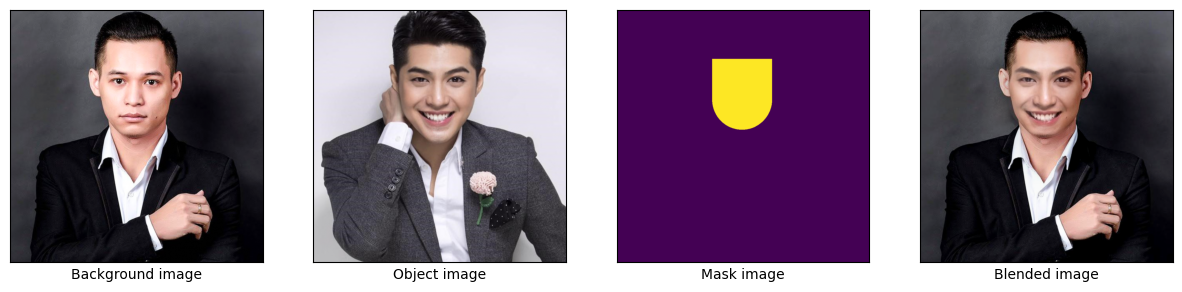

In [161]:
img1 = get_image('input/noo.png')
img2 = get_image('input/mixi.png')
mask = get_image('input/mask3.png', mask=True)

mask_stack = np.stack((mask.astype(float),)*3, axis=-1)
lap_blend = laplacian_blend(img1, img2, mask_stack, 5, 25)

show_images(
    [img2, img1, mask, lap_blend], 
    ["Background image", "Object image", "Mask image", "Blended image"]
)


In [152]:
def getSolutionVectTexture(indexes, target, mask, edges):
    w, h = target.shape[1], target.shape[0]
    x, y = np.meshgrid(np.arange(w), np.arange(h))

    x_left = (x-1).clip(0, w-1)
    left = target[y, x_left]
    indexes_left = indexes[y, x_left]

    x_right = (x+1).clip(0, w-1)
    right = target[y, x_right]
    indexes_right = indexes[y, x_right]

    y_up = (y-1).clip(0, h-1)
    up = target[y_up, x]
    indexes_up = indexes[y_up, x]

    y_down = (y+1).clip(0, h-1)
    down = target[y_down, x]
    indexes_down = indexes[y_down, x]

    Y, X = np.nonzero(indexes)
    N = np.count_nonzero(indexes)
    b = np.zeros((1, N))

    for (j, i) in list(zip(Y, X)):
      val = 0
      if edges[j][i] == 1:
        val += 4 * target[j][i] - target[j-1][i] - target[j+1][i] - target[j][i-1] - target[j][i+1]
      else:
        if edges[j][i-1] == 1:
          val += target[j][i] - target[j][i-1]
        if edges[j][i+1] == 1:
          val += target[j][i] - target[j][i+1]
        if edges[j-1][i] == 1:
          val += target[j][i] - target[j-1][i]
        if edges[j+1][i] == 1:
          val += target[j][i] - target[j+1][i]

      if indexes_left[j,i] == 0:
        val += left[j,i]
      if indexes_right[j,i] == 0:
        val += right[j,i]
      if indexes_up[j,i] == 0:
        val += up[j,i]
      if indexes_down[j,i] == 0:
        val += down[j,i]
      
      b[0][indexes[j][i]-1] = val

    return b


In [153]:
def PoissonTextureFlattening(targetImg, mask, edges):
    indexes = getIndexes(mask, targetImg.shape[0], targetImg.shape[1])
    A = getCoefficientMatrix(indexes)

    red, green, blue = [
        getSolutionVectTexture(indexes, targetImg[:, :, i], mask, edges).T for i in range(3)
    ]

    new_red, new_green, new_blue = [
        solveEqu(A, channel)
        for channel in [red, green, blue]
    ]

    resultImg = reconstructImg(indexes, new_red, new_green, new_blue,
                               targetImg)
    return resultImg

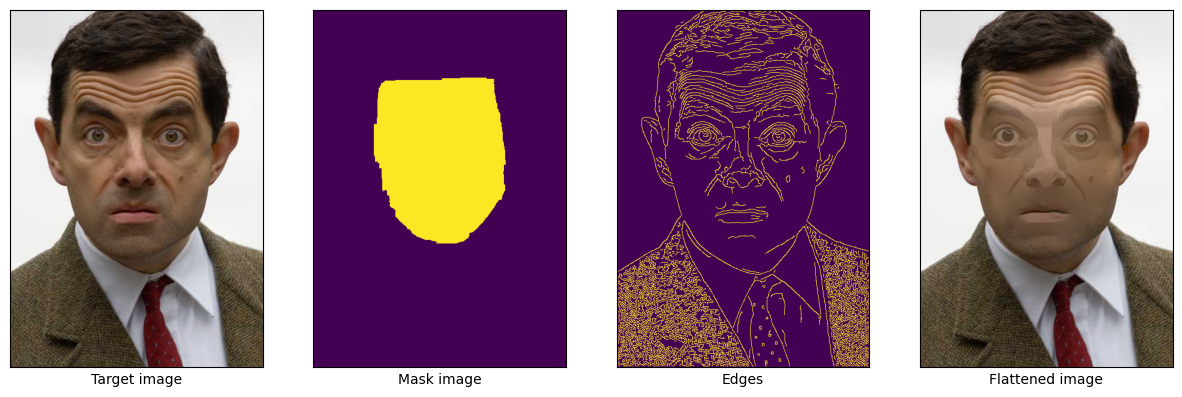

In [162]:
target_path  ='input/bean.jpg'
target = np.array(Image.open(target_path).convert('RGB'), 'f') / 255

from skimage.color import rgb2gray
from skimage import feature
edges = feature.canny(rgb2gray(target))

mask_path = 'input/mask_bean.bmp'
mask = np.array(Image.open(mask_path)) > 0
result = PoissonTextureFlattening(target, mask, edges)

flatten = Image.fromarray((np.clip(result, 0, 1) * 255).astype(np.uint8))
# flatten.save('flatten.png')

show_images(
    [target, mask, edges, result], 
    ["Target image", "Mask image", "Edges", "Flattened image"]
)

In [155]:
def rgb2gray(rgb: np.array) -> np.array:
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

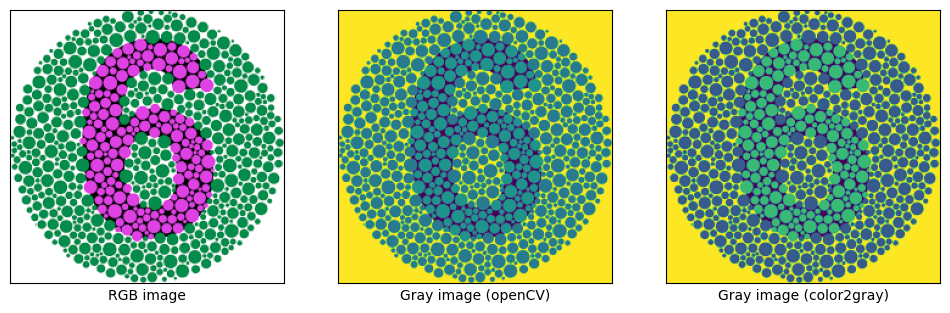

In [156]:
def color2gray(img: np.ndarray) -> np.ndarray:
    img_h, img_w = img.shape[:2]
    img_s = img.copy()
    img_t = rgb2gray(img.copy())
    
    im2var = np.arange(img_h * img_w).reshape(img_h, img_w) 
    
    A = sp.sparse.lil_matrix((img_h*img_w*4, img_h*img_w))
    b = np.zeros(img_h*img_w*4)
    
    e = 0
    for y in range(img_h):
        for x in range(img_w):
            dr = abs(img_s[y][x][0])
            dg = abs(img_s[y][x][1])
            db = abs(img_s[y][x][2])
            
            A[e, im2var[y][x]] = 1
            # b[e] = sum([img_s[y][x][n] for n in range(3)]) / 3
            b[e] = (float(img_s[y][x][0]) + float(img_s[y][x][1]) + float(img_s[y][x][2])) / 3.0
            e += 1
                    
    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]
    
    return v.reshape(img_h, img_w) 

# color_blind_img = get_image('input/image1.jpg', scale=False)
color_blind_img = get_image('input/image2.png', scale=False)
# color_blind_img = get_image('input/image3.webp', scale=False)
color2gray_img = color2gray(color_blind_img)
color2gray_img = (color2gray_img - color2gray_img.min()) / (color2gray_img.max() - color2gray_img.min())

show_images(
    [color_blind_img, cv2.cvtColor(color_blind_img, cv2.COLOR_BGR2GRAY), color2gray_img], 
    ["RGB image", "Gray image (openCV)", "Gray image (color2gray)"], 
    figsize=(12, 8)
)


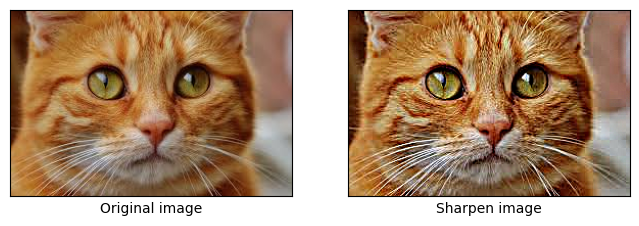

In [157]:
def poisson_sharpening(img: np.ndarray, alpha: int) -> np.ndarray:
    img_h, img_w = img.shape[:2]
    img_s = img.copy()
    
    im2var = np.arange(img_h * img_w).reshape(img_h, img_w) 
    
    A = sp.sparse.lil_matrix((img_h*img_w*4*2, img_h*img_w))
    b = np.zeros(img_h*img_w*4*2)
    
    e = 0
    for y in range(img_h):
        for x in range(img_w):
            A[e, im2var[y][x]] = 1
            b[e] = img_s[y][x]
            e += 1
            
            for n_y, n_x in neighbours(y, x, img_h-1, img_w-1):
                A[e, im2var[y][x]] = 1
                A[e, im2var[n_y][n_x]] = -1
                
                b[e] = alpha * (img_s[y][x] - img_s[n_y][n_x])
                e += 1
                
    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]

    return np.clip(v.reshape(img_h, img_w), 0, 1)

img = get_image('input/image4.jpeg')
alpha = 3.0

sharpen_img = np.zeros(img.shape)
for b in np.arange(3):
    sharpen_img[:,:,b] = poisson_sharpening(img[:,:,b], alpha)

show_images(
    [img, sharpen_img], 
    ["Original image", "Sharpen image"], 
    figsize=(8, 8)
)

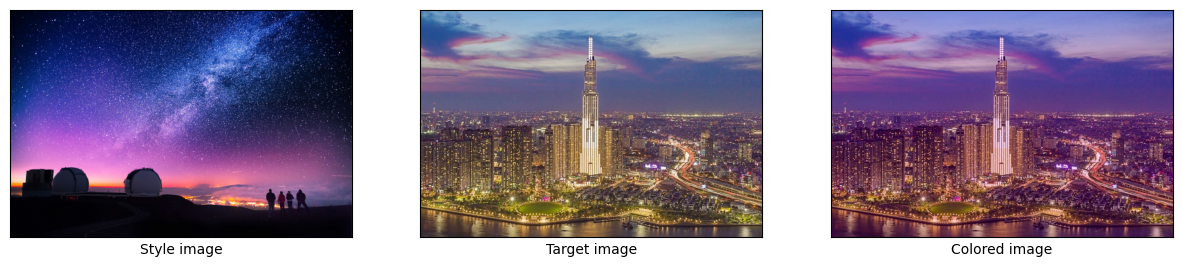

In [158]:
def color_transfer(img_s: np.ndarray, img_t: np.ndarray,alpha: int) -> np.ndarray:
    img_t_h, img_t_w = img_t.shape[:2]
        
    im2var = np.arange(img_t_h * img_t_w * 3).reshape((img_t_h, img_t_w, 3)) 
    
    A = sp.sparse.lil_matrix((img_t_h*img_t_w*3*5, img_t_h*img_t_w*3))
    b = np.zeros(img_t_h*img_t_w*3*5)
    
    e = 0
    for n in range(3):
        img_s_channel_avg = np.mean(img_s[:,:,n])
        img_s_channel_std = np.std(img_s[:,:,n])
        img_t_channel_avg = np.mean(img_t[:,:,n])
        img_t_channel_std = np.std(img_t[:,:,n])
        
        for y in range(img_t_h):
            for x in range(img_t_w):
                A[e, im2var[y][x][n]] = 1

                b[e] = img_t[y][x][n] - (img_t_channel_avg * (img_t_channel_std / img_s_channel_std) - img_s_channel_avg) * alpha
                e += 1
                
                for n_y, n_x in neighbours(y, x, img_t_h-1, img_t_w-1):
                    A[e, im2var[y][x][n]] = 1
                    A[e, im2var[n_y][n_x][n]] = -1
                    b[e] = img_t[y][x][n] - img_t[n_y][n_x][n]
                    e += 1
    
    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]
      
    return np.clip(v.reshape((img_t_h, img_t_w, 3)), 0, 1)

style_img = get_image('input/style.png')
target_img = get_image('input/target.webp')

alpha = 0.5

colored_img = color_transfer(style_img, target_img, alpha)

show_images(
    [style_img, target_img, colored_img], 
    ["Style image", "Target image", "Colored image"], 
    figsize=(15, 8)
)